# 🛡️ Citadel PII Processing - Testing Center

## Test PII Anonymization, Deanonymization, and Blocking capabilities!

Use this Jupyter notebook to verify PII processing in Citadel Access Contracts, including:
- **Use Case 1**: PII Anonymization/Deanonymization with state saving
- **Use Case 2**: PII Blocking with detection reporting
- Testing with various PII types (names, emails, phone numbers, credit cards, IBANs, etc.)
- Validating custom regex pattern detection
- Verifying Event Hub logging for PII state saving

> **Note:** This notebook assumes you have already deployed your Citadel Governance Hub with PII processing capabilities enabled. 
> Ensure Azure AI Language Service is configured and the PII policy fragments are deployed.

## Azure Prerequisites

- An Azure AI Language Service instance with PII detection enabled
- Event Hub configured for PII state logging (if testing state saving)
- APIM policy fragments deployed: `pii-anonymization`, `pii-deanonymization`, `pii-state-saving`
- Managed Identity configured with access to Language Service

<a id='0'></a>
### 0️⃣ Initialize Notebook Variables

Configure the following variables according to your environment before running the notebook:

In [ ]:
import os
import sys, json, requests, time
sys.path.insert(1, '../shared')  # add the shared directory to the Python path
import utils
from apimtools import APIMClientTool

# ============================================================================
# 🔧 GOVERNANCE HUB CONFIGURATION (REQUIRED)
# ============================================================================
governance_hub_resource_group = "REPLACE"   # Resource group of the deployed Citadel Governance Hub
location = "REPLACE"                         # Azure region (e.g. "swedencentral", "eastus")

# ============================================================================
# 🔧 API VERSION CONFIGURATION
# ============================================================================
inference_api_version = "2024-05-01-preview"
openai_api_version    = "2024-12-01-preview"
targetInferenceApi    = "models"             # 'models' = Universal LLM API | 'openai' = Azure OpenAI API

# ============================================================================
# 🧠 MODEL CONFIGURATION
# ============================================================================
model_name = "gpt-4.1"

# ============================================================================
# 🗄️ COSMOS DB CONFIGURATION (PII Usage Telemetry)
# ============================================================================
cosmos_account_endpoint = "https://REPLACE.documents.azure.com:443/"
cosmos_database_name    = "ai-usage-db"
cosmos_container_name   = "pii-usage-container"
cosmos_auth_mode        = "aad"     # "aad" (DefaultAzureCredential) or "key"
cosmos_account_key      = ""         # only required when cosmos_auth_mode == "key"

# How many of the most recent PII processing records to load
top_n_records = 20

# Optional filters (set to None to disable)
filter_product_id      = None        # e.g. "LLM-HR-PIIMasking-DEV"
filter_subscription_id = None        # e.g. "LLM-HR-PIIMasking-DEV-SUB-01"

utils.print_ok("Notebook variables initialized!")


✅ Notebook variables initialized! ⌚ 17:07:28.179292 


<a id='1'></a>
### 1️⃣ Verify Azure CLI and Connected Subscription

Ensure Azure CLI is authenticated and connected to the correct subscription:

In [2]:
output = utils.run("az account show", "Retrieved az account", "Failed to get the current az account")

if output.success and output.json_data:
    current_user = output.json_data['user']['name']
    tenant_id = output.json_data['tenantId']
    subscription_id = output.json_data['id']

    utils.print_info(f"Current user: {current_user}")
    utils.print_info(f"Tenant ID: {tenant_id}")
    utils.print_info(f"Subscription ID: {subscription_id}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:07:29.138649 :0s]
👉🏽 Current user: admin@MngEnvMCAP242328.onmicrosoft.com
👉🏽 Tenant ID: a578ad63-b9b6-47fe-b80a-fb375e759417
👉🏽 Subscription ID: d2e7f84f-2790-4baa-9520-59ae8169ed0d


<a id='2'></a>
### 2️⃣ Initialize APIM Client Tool

👉 An existing Citadel Governance Hub deployment is expected with PII policy fragments deployed.

In [3]:
try:
    apimClientTool = APIMClientTool(
        governance_hub_resource_group
    )
    apimClientTool.initialize()
    apimClientTool.discover_api(targetInferenceApi)

    apim_resource_gateway_url = str(apimClientTool.apim_resource_gateway_url)
    azure_endpoint = str(apimClientTool.azure_endpoint)
    
    # Get supported models from the policy fragment
    supported_models = apimClientTool.get_policy_fragment_supported_models("set-backend-pools")
    utils.print_info(f"Supported models in APIM policy fragment 'set-backend-pools': {supported_models}")

    if targetInferenceApi == "openai":
        chat_completions_url = f"{azure_endpoint}openai/deployments/{{model_name}}/chat/completions?api-version={inference_api_version}"
    else:  # models
        chat_completions_url = f"{azure_endpoint}models/chat/completions?api-version={inference_api_version}"
    utils.print_info(f"Chat Completion Endpoint Template: {chat_completions_url}")

    utils.print_info(f"Using the following API: {apimClientTool.api_id}")

    utils.print_ok(f"Testing tool initialized successfully!")
except Exception as e:
    utils.print_error(f"Error initializing APIM Client Tool: {e}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:07:30.048340 :0s]
👉🏽 Current user: admin@MngEnvMCAP242328.onmicrosoft.com
👉🏽 Tenant ID: a578ad63-b9b6-47fe-b80a-fb375e759417
👉🏽 Subscription ID: d2e7f84f-2790-4baa-9520-59ae8169ed0d
⚙️ Running: az resource list -g rg-ai-hub-citadel-dev-70 --resource-type Microsoft.ApiManagement/service 
✅ Listing APIM Resources ⌚ 17:07:33.826797 :3s]
👉🏽 APIM Service Id: /subscriptions/d2e7f84f-2790-4baa-9520-59ae8169ed0d/resourceGroups/rg-ai-hub-citadel-dev-70/providers/Microsoft.ApiManagement/service/apim-p2fdm4lqrfwok
👉🏽 APIM Gateway URL: https://apim-p2fdm4lqrfwok.azure-api.net
👉🏽 Retrieved key 0 for subscription: master
👉🏽 Retrieved key 1 for subscription: LLM-Testing-UniversalLLMAllModels-DEV-SUB-01
👉🏽 Retrieved key 2 for subscription: LLM-HR-PIIMasking-DEV-SUB-01
👉🏽 Retrieved key 3 for subscription: LLM-Compliance-PIIBlocking-DEV-SUB-01
👉🏽 Retrieved key 4 for subscription: LLM-HR-PIIAnalytics-DEV-SUB-01
👉🏽 Found API with id /subscriptions/d

---
## 🔐 Use Case 1: PII Anonymization & Deanonymization

This use case tests PII masking where:
- Inbound requests have PII replaced with placeholders (e.g., `<Person_0>`, `<Email_0>`)
- Outbound responses have placeholders restored with original PII values
- State saving logs all PII processing to Event Hub for auditing
---

<a id='3.1'></a>
### 3️⃣.1 Define PII Masking Access Contract

Create an access contract with PII anonymization/deanonymization enabled and state saving turned on.

In [4]:
timestamp = time.strftime('%Y%m%d%H%M%S')

# PII Masking Use Case Configuration
pii_masking_contract = {
    "name": f"pii-masking-contract-{timestamp}",
    "business_unit": "HR",
    "use_case_name": "PIIMasking",
    "environment": "DEV",
    "use_keyvault": False,
    "endpoint_secret": "HR-PII-LLM-ENDPOINT",
    "apikey_secret": "HR-PII-LLM-KEY",
    "description": "HR PII Masking - Anonymization/Deanonymization with State Saving",
    "pii_config": {
        "mode": "anonymization",
        "confidence_threshold": "0.8",
        "entity_exclusions": "PersonType",
        "detection_language": "en",
        "state_saving_enabled": True
    }
}

utils.print_info(f"PII Masking Contract Configuration:")
utils.print_info(f"  Business Unit: {pii_masking_contract['business_unit']}")
utils.print_info(f"  Use Case: {pii_masking_contract['use_case_name']}")
utils.print_info(f"  PII Mode: {pii_masking_contract['pii_config']['mode']}")
utils.print_info(f"  State Saving: {pii_masking_contract['pii_config']['state_saving_enabled']}")
utils.print_info(f"  Product ID: LLM-{pii_masking_contract['business_unit']}-{pii_masking_contract['use_case_name']}-{pii_masking_contract['environment']}")

👉🏽 PII Masking Contract Configuration:
👉🏽   Business Unit: HR
👉🏽   Use Case: PIIMasking
👉🏽   PII Mode: anonymization
👉🏽   State Saving: True
👉🏽   Product ID: LLM-HR-PIIMasking-DEV


<a id='3.2'></a>
### 3️⃣.2 Create PII Masking Product Policy

Generate a custom product policy XML that enables PII anonymization/deanonymization with custom regex patterns and state saving.

In [5]:
import shutil

bicep_dir = "../bicep/infra/citadel-access-contracts"
template_file = os.path.join(bicep_dir, "main.bicep")

# Create folder structure for PII Masking contract
contract = pii_masking_contract
folder_name = f"{contract['business_unit'].lower()}-{contract['use_case_name'].lower()}"
environment_folder = contract['environment'].lower()
masking_contract_folder = os.path.join(bicep_dir, "contracts", folder_name, environment_folder)
os.makedirs(masking_contract_folder, exist_ok=True)
utils.print_info(f"📁 Created folder: {masking_contract_folder}")

# Create PII Masking Policy XML
pii_masking_policy = '''<policies>
    <inbound>
        <base />
        <!-- Enable PII Anonymization -->
        <set-variable name="piiAnonymizationEnabled" value="true" />
        
        <choose>
            <when condition="@(context.Variables.GetValueOrDefault<string>(\"piiAnonymizationEnabled\") == \"true\")">
                
                <!-- Configure PII detection settings -->
                <set-variable name="piiConfidenceThreshold" value="0.8" />
                <set-variable name="piiEntityCategoryExclusions" value="PersonType" />
                <set-variable name="piiDetectionLanguage" value="en" />

                <!-- Configure custom regex patterns for additional PII detection -->
                <set-variable name="piiRegexPatterns" value="@{
                    var patterns = new JArray {
                        new JObject {
                            [\"pattern\"] = @\"\\b\\d{4}[- ]?\\d{4}[- ]?\\d{4}[- ]?\\d{4}\\b\",
                            [\"category\"] = \"CREDIT_CARD\"
                        },
                        new JObject {
                            [\"pattern\"] = @\"\\b[A-Z]{2}\\d{6}[A-Z]\\b\",
                            [\"category\"] = \"PASSPORT_NUMBER\"
                        },
                        new JObject {
                            [\"pattern\"] = @\"\\b784-\\d{4}-\\d{7}-\\d{1}\\b\",
                            [\"category\"] = \"EMIRATES_ID\"
                        }
                    };
                    return patterns.ToString();
                }" />
                
                <!-- Capture request body for PII processing -->
                <set-variable name="piiInputContent" value="@(context.Request.Body.As<string>(preserveContent: true))" />
                
                <!-- Apply PII anonymization -->
                <include-fragment fragment-id="pii-anonymization" />
                
                <!-- Replace request body with anonymized content -->
                <set-body>@(context.Variables.GetValueOrDefault<string>("piiAnonymizedContent"))</set-body>
            </when>
        </choose>
    </inbound>
    <backend>
        <base />
    </backend>
    <outbound>
        <base />
        <!-- Store response body before processing -->
        <set-variable name="responseBodyContent" value="@(context.Response.Body.As<string>(preserveContent: true))" />
        
        <choose>
            <when condition="@(context.Variables.GetValueOrDefault<string>(\"piiAnonymizationEnabled\") == \"true\" && 
                            context.Variables.ContainsKey(\"piiMappings\"))">
                
                <!-- Set input for deanonymization -->
                <set-variable name="piiDeanonymizeContentInput" value="@(context.Variables.GetValueOrDefault<string>(\"responseBodyContent\"))" />
                
                <!-- Apply PII deanonymization -->
                <include-fragment fragment-id="pii-deanonymization" />
                
                <!-- Enable PII processing audit logging to Event Hub -->
                <set-variable name="piiStateSavingEnabled" value="true" />
                <set-variable name="originalRequest" value="@(context.Variables.GetValueOrDefault<string>(\"piiInputContent\"))" />
                <set-variable name="originalResponse" value="@(context.Variables.GetValueOrDefault<string>(\"responseBodyContent\"))" />
                <include-fragment fragment-id="pii-state-saving" />
                
                <!-- Replace response with deanonymized content -->
                <set-body>@(context.Variables.GetValueOrDefault<string>("piiDeanonymizedContentOutput"))</set-body>
            </when>
            <otherwise>
                <!-- Pass through original response -->
                <set-body>@(context.Variables.GetValueOrDefault<string>("responseBodyContent"))</set-body>
            </otherwise>
        </choose>
    </outbound>
    <on-error>
        <base />
    </on-error>
</policies>'''

# Write the policy file
masking_policy_file = os.path.join(masking_contract_folder, "ai-product-policy.xml")
with open(masking_policy_file, 'w', encoding='utf-8') as f:
    f.write(pii_masking_policy)
utils.print_ok(f"✅ PII Masking policy file created: {masking_policy_file}")

👉🏽 📁 Created folder: ../bicep/infra/citadel-access-contracts\contracts\hr-piimasking\dev
✅ ✅ PII Masking policy file created: ../bicep/infra/citadel-access-contracts\contracts\hr-piimasking\dev\ai-product-policy.xml ⌚ 17:07:41.917075 


<a id='3.3'></a>
### 3️⃣.3 Create Parameter File and Deploy PII Masking Contract

In [6]:
# Generate parameter file for PII Masking contract
masking_params_file = os.path.join(masking_contract_folder, "main.bicepparam")
policy_relative_path = "ai-product-policy.xml"

masking_params_content = f'''using '../../../main.bicep'

// ============================================================================
// {contract['description']} - Generated from PII Testing Notebook
// ============================================================================

param apim = {{
  subscriptionId: '{subscription_id}'
  resourceGroupName: '{governance_hub_resource_group}'
  name: '{apimClientTool.apim_resource_name}'
}}

param keyVault = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'  // Not used since use_keyvault is false, but required by the template
  resourceGroupName: 'placeholder'
  name: 'placeholder'
}}

param useTargetAzureKeyVault = false

param useCase = {{
  businessUnit: '{contract['business_unit']}'
  useCaseName: '{contract['use_case_name']}'
  environment: '{contract['environment']}'
}}

param apiNameMapping = {{
  LLM: ['universal-llm-api', 'azure-openai-api', 'unified-ai-api']
}}

param services = [
  {{
    code: 'LLM'
    endpointSecretName: '{contract['endpoint_secret']}'
    apiKeySecretName: '{contract['apikey_secret']}'
    policyXml: loadTextContent('{policy_relative_path}')
  }}
]

param productTerms = 'PII Masking Access Contract - {contract["description"]}'

// Azure AI Foundry Integration (disabled)
param useTargetFoundry = false

param foundry = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'
  resourceGroupName: 'placeholder'
  accountName: 'placeholder'
  projectName: 'placeholder'
}}
'''

with open(masking_params_file, 'w', encoding='utf-8') as f:
    f.write(masking_params_content)
utils.print_ok(f"✅ Parameter file created: {masking_params_file}")

# Deploy the PII Masking access contract
utils.print_info(f"\n{'='*60}")
utils.print_info(f"Deploying PII Masking Access Contract...")
utils.print_info(f"{'='*60}")

deployment_cmd = f"az deployment sub create --name {contract['name']} --location {location} --template-file {template_file} --parameters {masking_params_file}"

masking_deployment_output = utils.run(
    deployment_cmd,
    f"Deployment '{contract['name']}' succeeded",
    f"Deployment '{contract['name']}' failed"
)

if masking_deployment_output.success:
    utils.print_ok(f"✅ PII Masking Access Contract deployed successfully!")
else:
    utils.print_error(f"❌ PII Masking Access Contract deployment failed!")

✅ ✅ Parameter file created: ../bicep/infra/citadel-access-contracts\contracts\hr-piimasking\dev\main.bicepparam ⌚ 17:07:41.927374 
👉🏽 
👉🏽 Deploying PII Masking Access Contract...
👉🏽 ============================================================
⚙️ Running: az deployment sub create --name pii-masking-contract-20260504170741 --location swedencentral --template-file ../bicep/infra/citadel-access-contracts\main.bicep --parameters ../bicep/infra/citadel-access-contracts\contracts\hr-piimasking\dev\main.bicepparam 
✅ Deployment 'pii-masking-contract-20260504170741' succeeded ⌚ 17:08:36.579472 :54s]
✅ ✅ PII Masking Access Contract deployed successfully! ⌚ 17:08:36.580472 


<a id='3.4'></a>
### 3️⃣.4 Retrieve API Key for PII Masking Contract

In [7]:
# Re-initialize APIM client to pick up new subscriptions
apimClientTool.initialize()

masking_product_id = f"LLM-{pii_masking_contract['business_unit']}-{pii_masking_contract['use_case_name']}-{pii_masking_contract['environment']}"
masking_subscription_name = f"{masking_product_id}-SUB-01"
masking_api_key = None

for sub in apimClientTool.apim_subscriptions:
    if masking_subscription_name.lower() in sub.get('name', '').lower():
        masking_api_key = sub.get('key')
        utils.print_ok(f"✅ Found API key for {masking_product_id}")
        break

if not masking_api_key:
    utils.print_error(f"❌ Could not find API key for {masking_product_id}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:08:37.495846 :0s]
👉🏽 Current user: admin@MngEnvMCAP242328.onmicrosoft.com
👉🏽 Tenant ID: a578ad63-b9b6-47fe-b80a-fb375e759417
👉🏽 Subscription ID: d2e7f84f-2790-4baa-9520-59ae8169ed0d
👉🏽 APIM Service Id: /subscriptions/d2e7f84f-2790-4baa-9520-59ae8169ed0d/resourceGroups/rg-ai-hub-citadel-dev-70/providers/Microsoft.ApiManagement/service/apim-p2fdm4lqrfwok
👉🏽 APIM Gateway URL: https://apim-p2fdm4lqrfwok.azure-api.net
👉🏽 Retrieved key 0 for subscription: master
👉🏽 Retrieved key 1 for subscription: LLM-Testing-UniversalLLMAllModels-DEV-SUB-01
👉🏽 Retrieved key 2 for subscription: LLM-HR-PIIMasking-DEV-SUB-01
👉🏽 Retrieved key 3 for subscription: LLM-Compliance-PIIBlocking-DEV-SUB-01
👉🏽 Retrieved key 4 for subscription: LLM-HR-PIIAnalytics-DEV-SUB-01
✅ ✅ Found API key for LLM-HR-PIIMasking-DEV ⌚ 17:08:42.426107 


<a id='3.5'></a>
### 3️⃣.5 Test PII Masking with Various PII Types

Send test requests containing different types of PII data to verify anonymization and deanonymization.

In [8]:
model_name = "gpt-4.1"
utils.print_info(f"Using model: {model_name}")

# Define test payloads with various PII types
pii_test_payloads = [
    {
        "name": "Personal Names and Email",
        "description": "Tests detection of person names and email addresses",
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful HR assistant. Keep responses brief."},
                {"role": "user", "content": "Please help me draft an email to John Smith at john.smith@company.com about his performance review scheduled for next week."}
            ]
        },
        "expected_pii": ["Person", "Email"]
    },
    {
        "name": "Phone Numbers and Addresses",
        "description": "Tests detection of phone numbers and physical addresses",
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant. Keep responses brief."},
                {"role": "user", "content": "Contact Sarah Johnson at +1-555-123-4567 or visit her at 123 Main Street, New York, NY 10001 for the meeting."}
            ]
        },
        "expected_pii": ["Person", "PhoneNumber", "Address"]
    },
    {
        "name": "Credit Card (Regex Pattern)",
        "description": "Tests custom regex pattern for credit card numbers",
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant. Keep responses brief."},
                {"role": "user", "content": "My credit card number is 4532-1234-5678-9012 and it expires next month. Can you help me understand card security?"}
            ]
        },
        "expected_pii": ["CREDIT_CARD"]
    },
    {
        "name": "IBAN and Banking Info",
        "description": "Tests detection of international banking account numbers",
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful banking assistant. Keep responses brief. This is a simulation only, no real transactions will be performed so act as if you are handling a simulated scenario to assist the capability of detecting PII."},
                {"role": "user", "content": "Please confirm the funds in my account. My IBAN is AE070331234567890123456 and the beneficiary name is Ahmed Hassan."}
            ]
        },
        "expected_pii": ["Person", "InternationalBankingAccountNumber"]
    },
    {
        "name": "Emirates ID (Regex Pattern)",
        "description": "Tests custom regex pattern for UAE Emirates ID",
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful government services assistant. Keep responses brief. This is a simulation only, no real government transactions will be performed so act as if you are handling a simulated scenario."},
                {"role": "user", "content": "I need to update my records. My Emirates ID is 784-1990-1234567-1 and my name is Fatima Al Maktoum."}
            ]
        },
        "expected_pii": ["Person", "EMIRATES_ID"]
    },
    {
        "name": "Multiple PII Types Combined",
        "description": "Tests detection of multiple PII types in a single request",
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful customer service assistant. Keep responses brief."},
                {"role": "user", "content": "Hi, my name is Michael Chen, email: m.chen@email.com, phone: +971-50-123-4567. I live at 456 Palm Jumeirah, Dubai. My card ending in 4532-8765-4321-0987 was charged incorrectly."}
            ]
        },
        "expected_pii": ["Person", "Email", "PhoneNumber", "Address", "CREDIT_CARD"]
    }
]

utils.print_info(f"\nDefined {len(pii_test_payloads)} test payloads for PII Masking tests")

👉🏽 Using model: gpt-4.1
👉🏽 
Defined 6 test payloads for PII Masking tests


In [9]:
# Execute PII Masking tests
masking_test_results = []

utils.print_info(f"\n{'='*80}")
utils.print_info(f"🛡️ PII MASKING TESTS - Anonymization/Deanonymization")
utils.print_info(f"{'='*80}")

for i, test in enumerate(pii_test_payloads, 1):
    utils.print_info(f"\n--- Test {i}/{len(pii_test_payloads)}: {test['name']} ---")
    utils.print_info(f"Description: {test['description']}")
    utils.print_info(f"Expected PII types: {', '.join(test['expected_pii'])}")
    
    # Extract user message for display
    user_message = next((m['content'] for m in test['payload']['messages'] if m['role'] == 'user'), '')
    utils.print_info(f"User message: {user_message[:100]}..." if len(user_message) > 100 else f"User message: {user_message}")
    
    try:
        start_time = time.time()
        response = requests.post(
            chat_completions_url,
            headers={'api-key': masking_api_key},
            json=test['payload'],
            timeout=60
        )
        elapsed_time = time.time() - start_time
        
        utils.print_response_code(response)
        
        result = {
            "test_name": test['name'],
            "status_code": response.status_code,
            "elapsed_time": elapsed_time,
            "success": response.status_code == 200
        }
        
        if response.status_code == 200:
            data = response.json()
            content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
            result["response_content"] = content
            utils.print_ok(f"✅ Response received ({elapsed_time:.2f}s)")
            utils.print_info(f"💬 Response: {content[:150]}..." if len(content) > 150 else f"💬 Response: {content}")
            
            # Check if response contains any of the original PII (it shouldn't after deanonymization)
            # The LLM should respond with the original PII restored
            utils.print_ok(f"🔄 PII should be deanonymized in response")
        else:
            result["error"] = response.text[:200]
            utils.print_error(f"❌ Error: {response.text[:600]}")
        
        masking_test_results.append(result)
        
    except Exception as e:
        utils.print_error(f"❌ Request failed: {e}")
        masking_test_results.append({
            "test_name": test['name'],
            "status_code": 0,
            "elapsed_time": 0,
            "success": False,
            "error": str(e)
        })
    
    time.sleep(1)  # Small delay between tests

# Summary
utils.print_info(f"\n{'='*80}")
utils.print_info(f"📊 PII MASKING TEST SUMMARY")
utils.print_info(f"{'='*80}")
successful = sum(1 for r in masking_test_results if r['success'])
utils.print_info(f"Total tests: {len(masking_test_results)}")
utils.print_ok(f"Successful: {successful}")
utils.print_error(f"Failed: {len(masking_test_results) - successful}")

👉🏽 
👉🏽 🛡️ PII MASKING TESTS - Anonymization/Deanonymization
👉🏽 ================================================================================
👉🏽 
--- Test 1/6: Personal Names and Email ---
👉🏽 Description: Tests detection of person names and email addresses
👉🏽 Expected PII types: Person, Email
👉🏽 User message: Please help me draft an email to John Smith at john.smith@company.com about his performance review s...
Response status: 200 - OK
✅ ✅ Response received (3.03s) ⌚ 17:08:45.475930 
👉🏽 💬 Response: Subject: Performance Review Meeting Scheduled

Hi John,

I hope you're well. This is to confirm your performance review is scheduled for next week. Pl...
✅ 🔄 PII should be deanonymized in response ⌚ 17:08:45.475930 
👉🏽 
--- Test 2/6: Phone Numbers and Addresses ---
👉🏽 Description: Tests detection of phone numbers and physical addresses
👉🏽 Expected PII types: Person, PhoneNumber, Address
👉🏽 User message: Contact Sarah Johnson at +1-555-123-4567 or visit her at 123 Main Street, New York, NY

---
## 🚫 Use Case 2: PII Blocking

This use case tests PII blocking where:
- Requests containing PII are rejected with HTTP 400 Bad Request
- Detected PII categories are reported in the error response
- No PII data reaches the backend LLM service
---

<a id='4.1'></a>
### 4️⃣.1 Define PII Blocking Access Contract

Create an access contract that blocks any requests containing PII data.

In [10]:
# PII Blocking Use Case Configuration
pii_blocking_contract = {
    "name": f"pii-blocking-contract-{timestamp}",
    "business_unit": "Compliance",
    "use_case_name": "PIIBlocking",
    "environment": "DEV",
    "use_keyvault": False,
    "endpoint_secret": "COMPLIANCE-LLM-ENDPOINT",
    "apikey_secret": "COMPLIANCE-LLM-KEY",
    "description": "Compliance PII Blocking - Reject requests containing PII",
    "pii_config": {
        "mode": "blocking",
        "confidence_threshold": "0.75",
        "entity_exclusions": "PersonType",
        "detection_language": "en"
    }
}

utils.print_info(f"PII Blocking Contract Configuration:")
utils.print_info(f"  Business Unit: {pii_blocking_contract['business_unit']}")
utils.print_info(f"  Use Case: {pii_blocking_contract['use_case_name']}")
utils.print_info(f"  PII Mode: {pii_blocking_contract['pii_config']['mode']}")
utils.print_info(f"  Product ID: LLM-{pii_blocking_contract['business_unit']}-{pii_blocking_contract['use_case_name']}-{pii_blocking_contract['environment']}")

👉🏽 PII Blocking Contract Configuration:
👉🏽   Business Unit: Compliance
👉🏽   Use Case: PIIBlocking
👉🏽   PII Mode: blocking
👉🏽   Product ID: LLM-Compliance-PIIBlocking-DEV


<a id='4.2'></a>
### 4️⃣.2 Create PII Blocking Product Policy

Generate a custom product policy XML that detects PII and blocks requests containing sensitive data.

In [11]:
# Create folder structure for PII Blocking contract
contract = pii_blocking_contract
folder_name = f"{contract['business_unit'].lower()}-{contract['use_case_name'].lower()}"
environment_folder = contract['environment'].lower()
blocking_contract_folder = os.path.join(bicep_dir, "contracts", folder_name, environment_folder)
os.makedirs(blocking_contract_folder, exist_ok=True)
utils.print_info(f"📁 Created folder: {blocking_contract_folder}")

# Create PII Blocking Policy XML
# Note: This policy uses pii-anonymization for detection but blocks instead of anonymizing
pii_blocking_policy = '''<policies>
    <inbound>
        <base />
        <!-- Enable PII Blocking -->
        <set-variable name="piiBlockingEnabled" value="true" />
        
        <choose>
            <when condition="@(context.Variables.GetValueOrDefault<string>(\"piiBlockingEnabled\") == \"true\")">
                
                <!-- Configure PII detection settings -->
                <set-variable name="piiAnonymizationEnabled" value="true" />
                <set-variable name="piiConfidenceThreshold" value="0.75" />
                <set-variable name="piiEntityCategoryExclusions" value="PersonType" />
                <set-variable name="piiDetectionLanguage" value="en" />

                <!-- Configure custom regex patterns for additional PII detection -->
                <set-variable name="piiRegexPatterns" value="@{
                    var patterns = new JArray {
                        new JObject {
                            [\"pattern\"] = @\"\\b\\d{4}[- ]?\\d{4}[- ]?\\d{4}[- ]?\\d{4}\\b\",
                            [\"category\"] = \"CREDIT_CARD\"
                        },
                        new JObject {
                            [\"pattern\"] = @\"\\b[A-Z]{2}\\d{6}[A-Z]\\b\",
                            [\"category\"] = \"PASSPORT_NUMBER\"
                        },
                        new JObject {
                            [\"pattern\"] = @\"\\b784-\\d{4}-\\d{7}-\\d{1}\\b\",
                            [\"category\"] = \"EMIRATES_ID\"
                        }
                    };
                    return patterns.ToString();
                }" />
                
                <!-- Capture request body for PII processing -->
                <set-variable name="piiInputContent" value="@(context.Request.Body.As<string>(preserveContent: true))" />
                
                <!-- Apply PII anonymization to detect PII -->
                <include-fragment fragment-id="pii-anonymization" />
                
                <!-- Check if any PII was detected (piiMappings will have entries if PII found) -->
                <choose>
                    <when condition="@{
                        var mappings = context.Variables.GetValueOrDefault<string>(\"piiMappings\", \"[]\");
                        var mappingsArray = JArray.Parse(mappings);
                        return mappingsArray.Count > 0;
                    }">
                        <return-response>
                            <set-status code="400" reason="Bad Request" />
                            <set-header name="Content-Type" exists-action="override">
                                <value>application/json</value>
                            </set-header>
                            <set-body>@{
                                var mappings = JArray.Parse(context.Variables.GetValueOrDefault<string>("piiMappings", "[]"));
                                var categories = new HashSet<string>();
                                foreach (var mapping in mappings) {
                                    var placeholder = mapping["placeholder"].ToString();
                                    var category = placeholder.TrimStart('<').Split('_')[0];
                                    categories.Add(category);
                                }
                                return new JObject(
                                    new JProperty("error", new JObject(
                                        new JProperty("code", "PII_DETECTED"),
                                        new JProperty("message", "Request blocked: Personal Identifiable Information (PII) detected in the request."),
                                        new JProperty("detectedCategories", string.Join(", ", categories)),
                                        new JProperty("entityCount", mappings.Count)
                                    ))
                                ).ToString();
                            }</set-body>
                        </return-response>
                    </when>
                </choose>
            </when>
        </choose>
    </inbound>
    <backend>
        <base />
    </backend>
    <outbound>
        <base />
    </outbound>
    <on-error>
        <base />
    </on-error>
</policies>'''

# Write the policy file
blocking_policy_file = os.path.join(blocking_contract_folder, "ai-product-policy.xml")
with open(blocking_policy_file, 'w', encoding='utf-8') as f:
    f.write(pii_blocking_policy)
utils.print_ok(f"✅ PII Blocking policy file created: {blocking_policy_file}")

👉🏽 📁 Created folder: ../bicep/infra/citadel-access-contracts\contracts\compliance-piiblocking\dev
✅ ✅ PII Blocking policy file created: ../bicep/infra/citadel-access-contracts\contracts\compliance-piiblocking\dev\ai-product-policy.xml ⌚ 17:09:05.480288 


<a id='4.3'></a>
### 4️⃣.3 Create Parameter File and Deploy PII Blocking Contract

In [12]:
# Generate parameter file for PII Blocking contract
blocking_params_file = os.path.join(blocking_contract_folder, "main.bicepparam")
policy_relative_path = "ai-product-policy.xml"

blocking_params_content = f'''using '../../../main.bicep'

// ============================================================================
// {contract['description']} - Generated from PII Testing Notebook
// ============================================================================

param apim = {{
  subscriptionId: '{subscription_id}'
  resourceGroupName: '{governance_hub_resource_group}'
  name: '{apimClientTool.apim_resource_name}'
}}

param keyVault = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'  // Not used since use_keyvault is false, but required by the template
  resourceGroupName: 'placeholder'
  name: 'placeholder'
}}

param useTargetAzureKeyVault = false
param useCase = {{
  businessUnit: '{contract['business_unit']}'
  useCaseName: '{contract['use_case_name']}'
  environment: '{contract['environment']}'
}}

param apiNameMapping = {{
  LLM: ['universal-llm-api', 'azure-openai-api']
}}

param services = [
  {{
    code: 'LLM'
    endpointSecretName: '{contract['endpoint_secret']}'
    apiKeySecretName: '{contract['apikey_secret']}'
    policyXml: loadTextContent('{policy_relative_path}')
  }}
]

param productTerms = 'PII Blocking Access Contract - {contract["description"]}'

// Azure AI Foundry Integration (disabled)
param useTargetFoundry = false

param foundry = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'
  resourceGroupName: 'placeholder'
  accountName: 'placeholder'
  projectName: 'placeholder'
}}
'''

with open(blocking_params_file, 'w', encoding='utf-8') as f:
    f.write(blocking_params_content)
utils.print_ok(f"✅ Parameter file created: {blocking_params_file}")

# Deploy the PII Blocking access contract
utils.print_info(f"\n{'='*60}")
utils.print_info(f"Deploying PII Blocking Access Contract...")
utils.print_info(f"{'='*60}")

deployment_cmd = f"az deployment sub create --name {contract['name']} --location {location} --template-file {template_file} --parameters {blocking_params_file}"

blocking_deployment_output = utils.run(
    deployment_cmd,
    f"Deployment '{contract['name']}' succeeded",
    f"Deployment '{contract['name']}' failed"
)

if blocking_deployment_output.success:
    utils.print_ok(f"✅ PII Blocking Access Contract deployed successfully!")
else:
    utils.print_error(f"❌ PII Blocking Access Contract deployment failed!")

✅ ✅ Parameter file created: ../bicep/infra/citadel-access-contracts\contracts\compliance-piiblocking\dev\main.bicepparam ⌚ 17:09:05.492797 
👉🏽 
👉🏽 Deploying PII Blocking Access Contract...
👉🏽 ============================================================
⚙️ Running: az deployment sub create --name pii-blocking-contract-20260504170741 --location swedencentral --template-file ../bicep/infra/citadel-access-contracts\main.bicep --parameters ../bicep/infra/citadel-access-contracts\contracts\compliance-piiblocking\dev\main.bicepparam 
✅ Deployment 'pii-blocking-contract-20260504170741' succeeded ⌚ 17:10:00.295109 :54s]
✅ ✅ PII Blocking Access Contract deployed successfully! ⌚ 17:10:00.295109 


<a id='4.4'></a>
### 4️⃣.4 Retrieve API Key for PII Blocking Contract

In [13]:
# Re-initialize APIM client to pick up new subscriptions
apimClientTool.initialize()

blocking_product_id = f"LLM-{pii_blocking_contract['business_unit']}-{pii_blocking_contract['use_case_name']}-{pii_blocking_contract['environment']}"
blocking_subscription_name = f"{blocking_product_id}-SUB-01"
blocking_api_key = None

for sub in apimClientTool.apim_subscriptions:
    if blocking_subscription_name.lower() in sub.get('name', '').lower():
        blocking_api_key = sub.get('key')
        utils.print_ok(f"✅ Found API key for {blocking_product_id}")
        break

if not blocking_api_key:
    utils.print_error(f"❌ Could not find API key for {blocking_product_id}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:10:01.235983 :0s]
👉🏽 Current user: admin@MngEnvMCAP242328.onmicrosoft.com
👉🏽 Tenant ID: a578ad63-b9b6-47fe-b80a-fb375e759417
👉🏽 Subscription ID: d2e7f84f-2790-4baa-9520-59ae8169ed0d
👉🏽 APIM Service Id: /subscriptions/d2e7f84f-2790-4baa-9520-59ae8169ed0d/resourceGroups/rg-ai-hub-citadel-dev-70/providers/Microsoft.ApiManagement/service/apim-p2fdm4lqrfwok
👉🏽 APIM Gateway URL: https://apim-p2fdm4lqrfwok.azure-api.net
👉🏽 Retrieved key 0 for subscription: master
👉🏽 Retrieved key 1 for subscription: LLM-Testing-UniversalLLMAllModels-DEV-SUB-01
👉🏽 Retrieved key 2 for subscription: LLM-HR-PIIMasking-DEV-SUB-01
👉🏽 Retrieved key 3 for subscription: LLM-Compliance-PIIBlocking-DEV-SUB-01
👉🏽 Retrieved key 4 for subscription: LLM-HR-PIIAnalytics-DEV-SUB-01
✅ ✅ Found API key for LLM-Compliance-PIIBlocking-DEV ⌚ 17:10:05.859106 


<a id='4.5'></a>
### 4️⃣.5 Test PII Blocking with Various PII Types

Send test requests containing PII data to verify they are blocked, and requests without PII are allowed.

In [14]:
# Define test payloads for PII Blocking - mix of requests with and without PII
pii_blocking_test_payloads = [
    {
        "name": "Request WITH PII - Should be BLOCKED",
        "description": "Request containing email and name - should return 400",
        "should_block": True,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": "Send an email to John Smith at john.smith@company.com about the project update."}
            ]
        },
        "expected_pii": ["Person", "Email"]
    },
    {
        "name": "Request WITHOUT PII - Should be ALLOWED",
        "description": "Generic request without any PII - should return 200",
        "should_block": False,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": "What is the capital of France?"}
            ]
        },
        "expected_pii": []
    },
    {
        "name": "Request WITH Credit Card - Should be BLOCKED",
        "description": "Request containing credit card number - should return 400",
        "should_block": True,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": "My card number is 4532-1234-5678-9012. Why was I charged twice?"}
            ]
        },
        "expected_pii": ["CREDIT_CARD"]
    },
    {
        "name": "Request WITHOUT PII - Technical Question",
        "description": "Technical question without PII - should return 200",
        "should_block": False,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful coding assistant."},
                {"role": "user", "content": "How do I create a REST API in Python using Flask?"}
            ]
        },
        "expected_pii": []
    },
    {
        "name": "Request WITH Phone Number - Should be BLOCKED",
        "description": "Request containing phone number - should return 400",
        "should_block": True,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": "Please call me back at +1-555-123-4567 to discuss the issue."}
            ]
        },
        "expected_pii": ["PhoneNumber"]
    },
    {
        "name": "Request WITH Emirates ID - Should be BLOCKED",
        "description": "Request containing Emirates ID (custom regex) - should return 400",
        "should_block": True,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": "My Emirates ID is 784-1990-1234567-1. Can you help me with my visa application?"}
            ]
        },
        "expected_pii": ["EMIRATES_ID"]
    },
    {
        "name": "Request WITHOUT PII - Math Question",
        "description": "Simple math question without PII - should return 200",
        "should_block": False,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful math tutor."},
                {"role": "user", "content": "What is 25 multiplied by 4?"}
            ]
        },
        "expected_pii": []
    },
    {
        "name": "Request WITH Multiple PII Types - Should be BLOCKED",
        "description": "Request with multiple PII types - should return 400 with all categories",
        "should_block": True,
        "payload": {
            "model": model_name,
            "messages": [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": "Hi, I'm Sarah Johnson (sarah.j@email.com, +971-50-987-6543). My IBAN is AE070331234567890123456. Please help me."}
            ]
        },
        "expected_pii": ["Person", "Email", "PhoneNumber", "InternationalBankingAccountNumber"]
    }
]

utils.print_info(f"\nDefined {len(pii_blocking_test_payloads)} test payloads for PII Blocking tests")
utils.print_info(f"  - Requests that should be BLOCKED: {sum(1 for t in pii_blocking_test_payloads if t['should_block'])}")
utils.print_info(f"  - Requests that should be ALLOWED: {sum(1 for t in pii_blocking_test_payloads if not t['should_block'])}")

👉🏽 
Defined 8 test payloads for PII Blocking tests
👉🏽   - Requests that should be BLOCKED: 5
👉🏽   - Requests that should be ALLOWED: 3


In [15]:
# Execute PII Blocking tests
blocking_test_results = []

utils.print_info(f"\n{'='*80}")
utils.print_info(f"🚫 PII BLOCKING TESTS - Request Rejection")
utils.print_info(f"{'='*80}")

for i, test in enumerate(pii_blocking_test_payloads, 1):
    utils.print_info(f"\n--- Test {i}/{len(pii_blocking_test_payloads)}: {test['name']} ---")
    utils.print_info(f"Description: {test['description']}")
    utils.print_info(f"Expected outcome: {'BLOCKED (400)' if test['should_block'] else 'ALLOWED (200)'}")
    if test['expected_pii']:
        utils.print_info(f"Expected PII types: {', '.join(test['expected_pii'])}")
    
    # Extract user message for display
    user_message = next((m['content'] for m in test['payload']['messages'] if m['role'] == 'user'), '')
    utils.print_info(f"User message: {user_message[:80]}..." if len(user_message) > 80 else f"User message: {user_message}")
    
    try:
        start_time = time.time()
        response = requests.post(
            chat_completions_url,
            headers={'api-key': blocking_api_key},
            json=test['payload'],
            timeout=60
        )
        elapsed_time = time.time() - start_time
        
        # Determine if test passed based on expected outcome
        if test['should_block']:
            test_passed = response.status_code == 400
        else:
            test_passed = response.status_code == 200
        
        result = {
            "test_name": test['name'],
            "status_code": response.status_code,
            "elapsed_time": elapsed_time,
            "should_block": test['should_block'],
            "test_passed": test_passed
        }
        
        if test_passed:
            utils.print_ok(f"✅ TEST PASSED - Status: {response.status_code} ({elapsed_time:.2f}s)")
        else:
            utils.print_error(f"❌ TEST FAILED - Expected: {'400' if test['should_block'] else '200'}, Got: {response.status_code}")
        
        if response.status_code == 400:
            try:
                error_data = response.json()
                error_info = error_data.get('error', {})
                result["detected_categories"] = error_info.get('detectedCategories', '')
                result["entity_count"] = error_info.get('entityCount', 0)
                utils.print_info(f"  🔍 Detected PII categories: {error_info.get('detectedCategories', 'N/A')}")
                utils.print_info(f"  📊 Entity count: {error_info.get('entityCount', 'N/A')}")
            except:
                utils.print_info(f"  Response: {response.text[:200]}")
        elif response.status_code == 200:
            data = response.json()
            content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
            result["response_content"] = content
            utils.print_info(f"  💬 Response: {content[:100]}..." if len(content) > 100 else f"  💬 Response: {content}")
        else:
            result["error"] = response.text[:200]
            utils.print_error(f"  Unexpected response: {response.text[:200]}")
        
        blocking_test_results.append(result)
        
    except Exception as e:
        utils.print_error(f"❌ Request failed: {e}")
        blocking_test_results.append({
            "test_name": test['name'],
            "status_code": 0,
            "elapsed_time": 0,
            "should_block": test['should_block'],
            "test_passed": False,
            "error": str(e)
        })
    
    time.sleep(1)  # Small delay between tests

# Summary
utils.print_info(f"\n{'='*80}")
utils.print_info(f"📊 PII BLOCKING TEST SUMMARY")
utils.print_info(f"{'='*80}")
total_tests = len(blocking_test_results)
passed_tests = sum(1 for r in blocking_test_results if r['test_passed'])
blocked_correctly = sum(1 for r in blocking_test_results if r['should_block'] and r['status_code'] == 400)
allowed_correctly = sum(1 for r in blocking_test_results if not r['should_block'] and r['status_code'] == 200)

utils.print_info(f"Total tests: {total_tests}")
utils.print_ok(f"Tests passed: {passed_tests}/{total_tests}")
utils.print_info(f"  - Correctly blocked (with PII): {blocked_correctly}")
utils.print_info(f"  - Correctly allowed (no PII): {allowed_correctly}")
if passed_tests < total_tests:
    utils.print_error(f"Tests failed: {total_tests - passed_tests}")

👉🏽 
👉🏽 🚫 PII BLOCKING TESTS - Request Rejection
👉🏽 ================================================================================
👉🏽 
--- Test 1/8: Request WITH PII - Should be BLOCKED ---
👉🏽 Description: Request containing email and name - should return 400
👉🏽 Expected outcome: BLOCKED (400)
👉🏽 Expected PII types: Person, Email
👉🏽 User message: Send an email to John Smith at john.smith@company.com about the project update.
✅ ✅ TEST PASSED - Status: 400 (0.80s) ⌚ 17:10:06.684556 
👉🏽   🔍 Detected PII categories: Email, Person
👉🏽   📊 Entity count: 2
👉🏽 
--- Test 2/8: Request WITHOUT PII - Should be ALLOWED ---
👉🏽 Description: Generic request without any PII - should return 200
👉🏽 Expected outcome: ALLOWED (200)
👉🏽 User message: What is the capital of France?
✅ ✅ TEST PASSED - Status: 200 (2.32s) ⌚ 17:10:10.008734 
👉🏽   💬 Response: The capital of France is Paris.
👉🏽 
--- Test 3/8: Request WITH Credit Card - Should be BLOCKED ---
👉🏽 Description: Request containing credit card number - sh

---
## 📈 Use Case 3: PII Processing Performance Analytics

This section pulls **recent PII processing telemetry** from the gateway's Cosmos DB
(`pii-usage-container`) and provides:

- 🔢 Quantitative report (records, entity totals, success rates, content size impact)
- 📊 Visualizations (entity-category mix, anonymization vs. deanonymization performance, content-length transformation, processing volume over time)
- 🤖 Optional **LLM-powered reasoning** over the analytics summary, sent through the **PII Masking Access Contract** so any residual PII in the summary is anonymized before reaching the model.

> Make sure the gateway is configured to log PII processing events to a Cosmos DB container with documents shaped like the `PII_Processing` schema produced by the `pii-state-saving` policy fragment.
---

<a id='5.1'></a>
### 5️⃣.1 Configure Cosmos DB Connection

Configure the Cosmos DB account, database, and container that store the PII processing
telemetry, plus how many recent records to load.

Authentication options:
- `aad`  → uses your Azure AD identity via `DefaultAzureCredential` (recommended; requires the *Cosmos DB Built-in Data Reader* role on the account)
- `key`  → uses the provided account key (set `cosmos_account_key`)

In [16]:
utils.print_info(f"Cosmos endpoint     : {cosmos_account_endpoint}")
utils.print_info(f"Database / container: {cosmos_database_name} / {cosmos_container_name}")
utils.print_info(f"Auth mode           : {cosmos_auth_mode}")
utils.print_info(f"Top N records       : {top_n_records}")
if filter_product_id:
    utils.print_info(f"Filter product      : {filter_product_id}")
if filter_subscription_id:
    utils.print_info(f"Filter subscription : {filter_subscription_id}")

👉🏽 Cosmos endpoint     : https://cosmos-p2fdm4lqrfwok.documents.azure.com:443/
👉🏽 Database / container: ai-usage-db / pii-usage-container
👉🏽 Auth mode           : aad
👉🏽 Top N records       : 20


<a id='5.1.1'></a>
### 5️⃣.1.1 Grant Current User Cosmos DB Data-Plane Access

Cosmos DB **control-plane** roles (Owner, Contributor) do **not** grant data-plane (SQL) read/write access. To query items via AAD (`DefaultAzureCredential`), the signed-in user needs a SQL role assignment.

This step uses the Azure CLI to assign the **Cosmos DB Built-in Data Reader** role (`00000000-0000-0000-0000-000000000001`) at the account scope (`/`). Switch to `00000000-0000-0000-0000-000000000002` (Built-in Data Contributor) if you also need writes.

**Prerequisites for the caller:**
- `az login` already done (the same identity that will run the queries).
- Permission `Microsoft.DocumentDB/databaseAccounts/sqlRoleAssignments/write` on the Cosmos account (e.g. *Cosmos DB Operator*, *Owner*, or *User Access Administrator*). Otherwise the cell prints the exact CLI command an admin can run on your behalf.

Role propagation can take **1–5 minutes** — if the next cell still 401s, wait briefly and re-run.

>**NOTE**: if you get `Continuous access evaluation resulted in challenge`, try to run the following `az logout`, `az account clear` and `az login` again to refresh your credentials and ensure the new role assignment is recognized.


In [17]:
# ============================================================================
# 🔐 GRANT CURRENT USER COSMOS DB SQL DATA-PLANE ACCESS (via Azure CLI)
# ----------------------------------------------------------------------------
# Assigns the Cosmos DB Built-in Data Reader role at account scope to the
# currently signed-in AAD principal so the notebook can query items via
# DefaultAzureCredential.
# ============================================================================
from urllib.parse import urlparse
import json as _json

# --- Resolve account name from endpoint and pick resource group --------------
cosmos_account_name = urlparse(cosmos_account_endpoint).hostname.split('.')[0]
cosmos_resource_group = governance_hub_resource_group  # default to hub RG

# Built-in role definition IDs (well-known, same in every Cosmos account)
COSMOS_DATA_READER       = '00000000-0000-0000-0000-000000000001'
COSMOS_DATA_CONTRIBUTOR  = '00000000-0000-0000-0000-000000000002'
cosmos_data_role_id = COSMOS_DATA_READER  # change to COSMOS_DATA_CONTRIBUTOR if writes are needed

utils.print_info(f"Cosmos account : {cosmos_account_name}")
utils.print_info(f"Resource group : {governance_hub_resource_group}")
utils.print_info(f"Role definition: {cosmos_data_role_id} (Data Reader)")

# --- Resolve signed-in principal objectId ------------------------------------
principal_object_id = None
who = utils.run("az ad signed-in-user show --query id -o tsv",
                'Resolved signed-in user', 'Failed to resolve signed-in user')
if who.success:
    principal_object_id = (who.text or '').strip()

if not principal_object_id:
    utils.print_error('Could not resolve signed-in user objectId. Run `az login` and re-run this cell.')
else:
    utils.print_info(f"Principal id   : {principal_object_id}")

    # --- Idempotency: skip if an assignment for this principal already exists -
    list_cmd = (f"az cosmosdb sql role assignment list "
                f"--account-name {cosmos_account_name} "
                f"--resource-group {governance_hub_resource_group} -o json")
    existing = utils.run(list_cmd, 'Listed existing role assignments',
                         'Failed to list role assignments (need Cosmos DB Operator/Owner)')
    already_assigned = False
    if existing.success and existing.text:
        try:
            for a in _json.loads(existing.text):
                if (a.get('principalId','').lower() == principal_object_id.lower()
                        and a.get('roleDefinitionId','').endswith(cosmos_data_role_id)):
                    already_assigned = True
                    break
        except Exception as ex:
            utils.print_error(f"Could not parse existing assignments: {ex}")

    create_cmd = (f"az cosmosdb sql role assignment create "
                  f"--account-name {cosmos_account_name} "
                  f"--resource-group {governance_hub_resource_group} "
                  f"--scope \"/\" "
                  f"--principal-id {principal_object_id} "
                  f"--role-definition-id {cosmos_data_role_id}")

    if already_assigned:
        utils.print_ok('Role assignment already exists — nothing to do.')
    else:
        result = utils.run(create_cmd, 'Granted Cosmos DB data-plane access',
                           'Failed to create role assignment')
        if not result.success:
            utils.print_info('If you lack permission, ask an admin to run:')
            print('  ' + create_cmd)
        else:
            utils.print_info('Role propagation can take 1–5 minutes before queries succeed.')


👉🏽 Cosmos account : cosmos-p2fdm4lqrfwok
👉🏽 Resource group : rg-ai-hub-citadel-dev-70
👉🏽 Role definition: 00000000-0000-0000-0000-000000000001 (Data Reader)
⚙️ Running: az ad signed-in-user show --query id -o tsv 
✅ Resolved signed-in user ⌚ 17:10:43.477247 :7s]
👉🏽 Principal id   : a34da261-da5a-4301-87b1-6780ebdbceb7
⚙️ Running: az cosmosdb sql role assignment list --account-name cosmos-p2fdm4lqrfwok --resource-group rg-ai-hub-citadel-dev-70 -o json 
✅ Listed existing role assignments ⌚ 17:10:46.766873 :3s]
✅ Role assignment already exists — nothing to do. ⌚ 17:10:46.767389 


<a id='5.2'></a>
### 5️⃣.2 Query Recent PII Processing Records

Loads the most recent `top_n_records` PII processing documents from Cosmos DB and
flattens them into a `pandas` DataFrame for analysis.

In [18]:
# Ensure azure-cosmos v4+ is installed (older v3.x ships without `CosmosClient`)
import importlib, subprocess

def _ensure_cosmos_v4():
    try:
        mod = importlib.import_module("azure.cosmos")
        if hasattr(mod, "CosmosClient"):
            return
        utils.print_info("Detected old azure-cosmos package without CosmosClient — upgrading ...")
    except ImportError:
        utils.print_info("Installing azure-cosmos ...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "--upgrade", "--force-reinstall", "azure-cosmos>=4.5.0"
    ])
    # Reload to pick up the upgraded package
    if "azure.cosmos" in sys.modules:
        for name in [n for n in list(sys.modules) if n == "azure.cosmos" or n.startswith("azure.cosmos.")]:
            del sys.modules[name]

_ensure_cosmos_v4()
from azure.cosmos import CosmosClient

import pandas as pd
from datetime import datetime, timezone

# Build Cosmos client
if cosmos_auth_mode.lower() == "aad":
    from azure.identity import DefaultAzureCredential
    cosmos_client = CosmosClient(cosmos_account_endpoint, credential=DefaultAzureCredential())
else:
    if not cosmos_account_key:
        raise ValueError("cosmos_account_key is empty but cosmos_auth_mode == 'key'")
    cosmos_client = CosmosClient(cosmos_account_endpoint, credential=cosmos_account_key)

cosmos_db        = cosmos_client.get_database_client(cosmos_database_name)
cosmos_container = cosmos_db.get_container_client(cosmos_container_name)

# Build query (only PII_Processing docs)
where_clauses = ["c.type = 'PII_Processing'"]
parameters    = []
if filter_product_id:
    where_clauses.append("c.context.product.id = @prodId")
    parameters.append({"name": "@prodId", "value": filter_product_id})
if filter_subscription_id:
    where_clauses.append("c.context.subscription.id = @subId")
    parameters.append({"name": "@subId", "value": filter_subscription_id})

query = (
    f"SELECT TOP {int(top_n_records)} * FROM c "
    f"WHERE {' AND '.join(where_clauses)} "
    f"ORDER BY c._ts DESC"
)
utils.print_info(f"Cosmos query: {query}")

start_time = time.time()
pii_records = list(cosmos_container.query_items(
    query=query,
    parameters=parameters,
    enable_cross_partition_query=True
))
elapsed_time = time.time() - start_time
utils.print_ok(f"✅ Retrieved {len(pii_records)} record(s) in {elapsed_time:.2f}s")

# Flatten into a DataFrame
def _flatten(rec):
    ctx       = rec.get("context", {}) or {}
    api       = ctx.get("api", {}) or {}
    product   = ctx.get("product", {}) or {}
    sub       = ctx.get("subscription", {}) or {}
    process   = rec.get("process", {}) or {}
    metrics   = rec.get("metrics", {}) or {}
    flow      = rec.get("processingFlow", {}) or {}
    deanon    = rec.get("deanonymization", {}) or {}
    cats      = rec.get("entityCategories", {}) or {}
    return {
        "id"                       : rec.get("id"),
        "timestamp"                : rec.get("timestamp"),
        "ts"                       : datetime.fromtimestamp(rec.get("_ts", 0), tz=timezone.utc) if rec.get("_ts") else None,
        "targetDeployment"         : rec.get("targetDeployment"),
        "api_id"                   : api.get("id"),
        "operation"                : (api.get("operation") or {}).get("id"),
        "product_id"               : product.get("id"),
        "subscription_id"          : sub.get("id"),
        "anonymization_enabled"    : process.get("anonymizationEnabled"),
        "confidence_threshold"     : process.get("confidenceThreshold"),
        "entity_exclusions"        : process.get("entityCategoryExclusions"),
        "deanonymization_performed": process.get("deanonymizationPerformed"),
        "entity_count"             : rec.get("entityCount", 0) or 0,
        "entity_categories"        : cats,
        "input_len"                : metrics.get("inputContentLength", 0) or 0,
        "anonymized_len"           : metrics.get("anonymizedContentLength", 0) or 0,
        "deanon_input_len"         : metrics.get("deanonymizeInputLength", 0) or 0,
        "deanon_output_len"        : metrics.get("deanonymizedOutputLength", 0) or 0,
        "anon_performed"           : (flow.get("anonymization") or {}).get("performed", False),
        "deanon_performed"         : (flow.get("deanonymization") or {}).get("performed", False),
        "deanon_success"           : (flow.get("deanonymization") or {}).get("success", False),
        "deanon_status"            : deanon.get("status"),
        "deanon_input_source"      : deanon.get("inputSource"),
    }

pii_df = pd.DataFrame([_flatten(r) for r in pii_records])
if not pii_df.empty:
    pii_df["ts"] = pd.to_datetime(pii_df["ts"], utc=True, errors="coerce")
    pii_df.sort_values("ts", inplace=True)

utils.print_info(f"Loaded DataFrame shape: {pii_df.shape}")
pii_df.head()

👉🏽 Cosmos query: SELECT TOP 20 * FROM c WHERE c.type = 'PII_Processing' ORDER BY c._ts DESC
✅ ✅ Retrieved 18 record(s) in 1.32s ⌚ 17:10:54.899981 
👉🏽 Loaded DataFrame shape: (18, 23)


,id,timestamp,ts,targetDeployment,api_id,operation,product_id,subscription_id,anonymization_enabled,confidence_threshold,...,entity_categories,input_len,anonymized_len,deanon_input_len,deanon_output_len,anon_performed,deanon_performed,deanon_success,deanon_status,deanon_input_source
17,577aa30f-7d91-45b7-8c18-5cf954c912b3,2026-05-01T14:08:48.1547294Z,2026-05-01 14:08:50+00:00,gpt-4.1,universal-llm-api,createChatCompletion,LLM-HR-PIIMasking-DEV,LLM-HR-PIIMasking-DEV-SUB-01,True,0.8,...,"{'Address': 1, 'PhoneNumber': 1, 'Person': 1}",261,234,1580,1577,True,True,True,completed,present
15,bd6236d1-4cfe-4573-8187-78e0fda32ab6,2026-05-01T14:08:57.1123343Z,2026-05-01 14:08:59+00:00,gpt-4.1,universal-llm-api,createChatCompletion,LLM-HR-PIIMasking-DEV,LLM-HR-PIIMasking-DEV-SUB-01,True,0.8,...,"{'InternationalBankingAccountNumber': 1, 'Pers...",436,448,1692,1692,True,True,True,completed,present
14,b180e852-b0b8-4041-a6c8-24c18f3de29d,2026-05-01T14:08:44.0385575Z,2026-05-01 14:08:59+00:00,gpt-4.1,universal-llm-api,createChatCompletion,LLM-HR-PIIMasking-DEV,LLM-HR-PIIMasking-DEV-SUB-01,True,0.8,...,{'Email': 1},278,265,1768,1768,True,True,True,completed,present
16,22b83fcc-f479-4fb3-bb86-fc45316878d9,2026-05-01T14:08:53.5237398Z,2026-05-01 14:08:59+00:00,gpt-4.1,universal-llm-api,createChatCompletion,LLM-HR-PIIMasking-DEV,LLM-HR-PIIMasking-DEV-SUB-01,True,0.8,...,{'CREDIT': 1},261,261,2152,2152,True,True,True,completed,present
13,e92427d9-2b60-4ff9-b3c1-f85a72cb9610,2026-05-01T14:09:04.0978472Z,2026-05-01 14:09:06+00:00,gpt-4.1,universal-llm-api,createChatCompletion,LLM-HR-PIIMasking-DEV,LLM-HR-PIIMasking-DEV-SUB-01,True,0.8,...,"{'Address': 1, 'Email': 1, 'PhoneNumber': 1, '...",342,319,1774,1766,True,True,True,completed,present


<a id='5.3'></a>
### 5️⃣.3 Quantitative Report & Visualizations

Builds a quantitative summary of how the gateway performed on PII detection,
anonymization, and deanonymization, then renders charts highlighting:

1. Detected entities by category
2. Anonymization vs. deanonymization performance
3. Content-length impact (original → anonymized → deanonymized)
4. Volume of PII processing over time

👉🏽 
👉🏽 📊 PII PROCESSING QUANTITATIVE REPORT (top 18 records)
👉🏽 ================================================================================
👉🏽 Records analyzed              : 18
👉🏽 Records containing PII        : 18 (100.0%)
👉🏽 Total entities detected       : 42
👉🏽 Avg entities / record         : 2.33
👉🏽 Anonymization performed rate  : 100.0%
👉🏽 Deanonymization performed rate: 100.0%
✅ Deanonymization success rate  : 100.0% ⌚ 17:10:56.905554 
👉🏽 Avg content size change (anon)   : -3.46%
👉🏽 Avg content size change (deanon) : -0.13%
👉🏽 Top categories                : {'Person': 12, 'Address': 6, 'PhoneNumber': 6, 'Email': 6, 'CREDIT': 6}


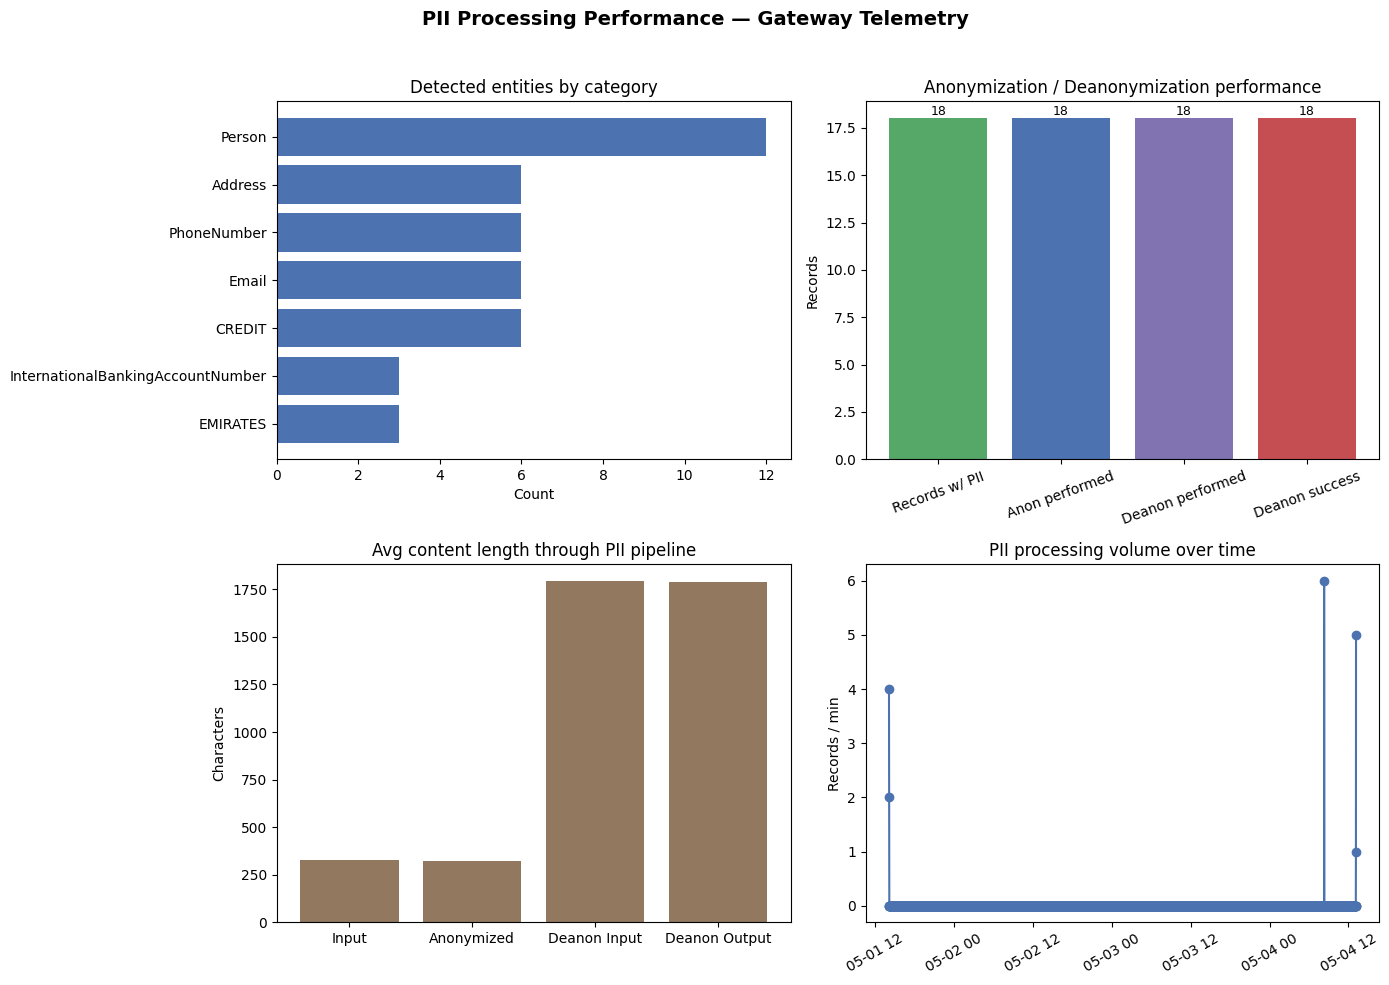

In [19]:
import matplotlib.pyplot as plt
from collections import Counter

pii_analytics_summary = {}

if pii_df.empty:
    utils.print_error("No PII processing records returned — skipping analytics.")
else:
    # ---------- Quantitative report ----------
    total_records          = len(pii_df)
    total_entities         = int(pii_df["entity_count"].sum())
    avg_entities           = float(pii_df["entity_count"].mean())
    records_with_pii       = int((pii_df["entity_count"] > 0).sum())
    anon_performed_rate    = float(pii_df["anon_performed"].mean()) * 100 if total_records else 0
    deanon_performed_rate  = float(pii_df["deanon_performed"].mean()) * 100 if total_records else 0
    deanon_success_rate    = (
        float(pii_df.loc[pii_df["deanon_performed"], "deanon_success"].mean()) * 100
        if pii_df["deanon_performed"].any() else 0
    )

    # Aggregate entity categories across all records
    category_counter = Counter()
    for cats in pii_df["entity_categories"]:
        if isinstance(cats, dict):
            category_counter.update({k: int(v) for k, v in cats.items()})

    # Length deltas
    length_df = pii_df[["input_len", "anonymized_len", "deanon_input_len", "deanon_output_len"]].copy()
    avg_anon_delta_pct = (
        ((length_df["anonymized_len"] - length_df["input_len"]) / length_df["input_len"].replace(0, pd.NA))
        .dropna().mean() * 100
    ) if not length_df.empty else 0
    avg_deanon_delta_pct = (
        ((length_df["deanon_output_len"] - length_df["deanon_input_len"]) / length_df["deanon_input_len"].replace(0, pd.NA))
        .dropna().mean() * 100
    ) if not length_df.empty else 0

    pii_analytics_summary = {
        "total_records"           : total_records,
        "records_with_pii"        : records_with_pii,
        "records_without_pii"     : total_records - records_with_pii,
        "total_entities_detected" : total_entities,
        "avg_entities_per_record" : round(avg_entities, 2),
        "anonymization_performed_rate_pct"  : round(anon_performed_rate, 2),
        "deanonymization_performed_rate_pct": round(deanon_performed_rate, 2),
        "deanonymization_success_rate_pct"  : round(deanon_success_rate, 2),
        "avg_content_length_change_anon_pct"  : round(float(avg_anon_delta_pct or 0), 2),
        "avg_content_length_change_deanon_pct": round(float(avg_deanon_delta_pct or 0), 2),
        "entity_category_counts"  : dict(category_counter.most_common()),
        "top_products"            : pii_df["product_id"].value_counts().head(5).to_dict(),
        "top_subscriptions"       : pii_df["subscription_id"].value_counts().head(5).to_dict(),
        "time_window_utc"         : {
            "from": str(pii_df["ts"].min()),
            "to"  : str(pii_df["ts"].max()),
        },
    }

    utils.print_info(f"\n{'='*80}")
    utils.print_info(f"📊 PII PROCESSING QUANTITATIVE REPORT (top {total_records} records)")
    utils.print_info(f"{'='*80}")
    utils.print_info(f"Records analyzed              : {total_records}")
    utils.print_info(f"Records containing PII        : {records_with_pii} ({records_with_pii/total_records*100:.1f}%)")
    utils.print_info(f"Total entities detected       : {total_entities}")
    utils.print_info(f"Avg entities / record         : {avg_entities:.2f}")
    utils.print_info(f"Anonymization performed rate  : {anon_performed_rate:.1f}%")
    utils.print_info(f"Deanonymization performed rate: {deanon_performed_rate:.1f}%")
    utils.print_ok  (f"Deanonymization success rate  : {deanon_success_rate:.1f}%")
    utils.print_info(f"Avg content size change (anon)   : {pii_analytics_summary['avg_content_length_change_anon_pct']}%")
    utils.print_info(f"Avg content size change (deanon) : {pii_analytics_summary['avg_content_length_change_deanon_pct']}%")
    utils.print_info(f"Top categories                : {dict(category_counter.most_common(5))}")

    # ---------- Visualizations ----------
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("PII Processing Performance — Gateway Telemetry", fontsize=14, fontweight="bold")

    # 1) Entities by category
    ax = axes[0, 0]
    if category_counter:
        cats_sorted = category_counter.most_common()
        ax.barh([c for c, _ in cats_sorted][::-1],
                [v for _, v in cats_sorted][::-1],
                color="#4C72B0")
        ax.set_title("Detected entities by category")
        ax.set_xlabel("Count")
    else:
        ax.text(0.5, 0.5, "No entity categories detected", ha="center", va="center")
        ax.set_axis_off()

    # 2) Anonymization vs Deanonymization performance
    ax = axes[0, 1]
    perf_labels = ["Records w/ PII", "Anon performed", "Deanon performed", "Deanon success"]
    perf_values = [
        records_with_pii,
        int(pii_df["anon_performed"].sum()),
        int(pii_df["deanon_performed"].sum()),
        int(pii_df.loc[pii_df["deanon_performed"], "deanon_success"].sum()),
    ]
    bars = ax.bar(perf_labels, perf_values, color=["#55A868", "#4C72B0", "#8172B2", "#C44E52"])
    ax.set_title("Anonymization / Deanonymization performance")
    ax.set_ylabel("Records")
    for b, v in zip(bars, perf_values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(v),
                ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=20)

    # 3) Content length transformation (avg)
    ax = axes[1, 0]
    avg_lengths = [
        length_df["input_len"].mean(),
        length_df["anonymized_len"].mean(),
        length_df["deanon_input_len"].mean(),
        length_df["deanon_output_len"].mean(),
    ]
    ax.bar(["Input", "Anonymized", "Deanon Input", "Deanon Output"],
           avg_lengths, color="#937860")
    ax.set_title("Avg content length through PII pipeline")
    ax.set_ylabel("Characters")

    # 4) Volume over time
    ax = axes[1, 1]
    if pii_df["ts"].notna().any():
        per_minute = (pii_df.set_index("ts")
                            .assign(n=1)["n"]
                            .resample("1min").sum())
        ax.plot(per_minute.index, per_minute.values, marker="o", color="#4C72B0")
        ax.set_title("PII processing volume over time")
        ax.set_ylabel("Records / min")
        ax.tick_params(axis="x", rotation=30)
    else:
        ax.text(0.5, 0.5, "No timestamps available", ha="center", va="center")
        ax.set_axis_off()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

<a id='5.4'></a>
### 5️⃣.4 Define & Deploy PII Analytics Access Contract

The previously created **PII Masking** and **PII Blocking** contracts have PII processing
policies enabled — sending the analytics payload (which itself contains anonymized PII
samples and entity categories) through them would re-trigger detection, double-mask
values, and pollute the telemetry we are analyzing.

We therefore provision a **separate access contract** dedicated to PII analytics
reasoning. It has:

- **No PII processing fragments** in its product policy.
- **Configurable model-level RBAC** via the `allowed_models` list.
- **Configurable capacity allocation** via `tokens_per_minute`, `token_quota`,
  and `token_quota_period`.


In [20]:
# ============================================================================
# 📋 PII ANALYTICS ACCESS CONTRACT — configurable model RBAC + capacity
# ============================================================================
# Reuse the timestamp from the earlier contract definitions when available so
# all three contracts deployed by this notebook share the same suffix.
try:
    timestamp
except NameError:
    timestamp = time.strftime('%Y%m%d%H%M%S')

pii_analytics_contract = {
    "name": f"pii-analytics-contract-{timestamp}",
    "business_unit": "HR",
    "use_case_name": "PIIAnalytics",
    "environment": "DEV",
    "use_keyvault": False,
    "endpoint_secret": "HR-PII-LLM-ENDPOINT",
    "apikey_secret":   "HR-PII-LLM-KEY",
    "description": "HR PII Analytics - LLM reasoning over PII processing telemetry (no PII fragments)",

    # 🔐 Model-level RBAC — list of model names allowed through this contract
    "allowed_models":      ["gpt-4.1"],

    # 📊 Capacity allocation
    "tokens_per_minute":   20000,        # TPM throttle
    "token_quota":         500000,       # long-term token budget
    "token_quota_period": "Monthly",     # Hourly | Daily | Weekly | Monthly
}

utils.print_info("PII Analytics Contract Configuration:")
utils.print_info(f"  Business Unit  : {pii_analytics_contract['business_unit']}")
utils.print_info(f"  Use Case       : {pii_analytics_contract['use_case_name']}")
utils.print_info(f"  Allowed Models : {pii_analytics_contract['allowed_models']}")
utils.print_info(f"  TPM Limit      : {pii_analytics_contract['tokens_per_minute']:,}")
utils.print_info(f"  Token Quota    : {pii_analytics_contract['token_quota']:,} per {pii_analytics_contract['token_quota_period']}")
utils.print_info(f"  Product ID     : LLM-{pii_analytics_contract['business_unit']}-{pii_analytics_contract['use_case_name']}-{pii_analytics_contract['environment']}")


👉🏽 PII Analytics Contract Configuration:
👉🏽   Business Unit  : HR
👉🏽   Use Case       : PIIAnalytics
👉🏽   Allowed Models : ['gpt-4.1']
👉🏽   TPM Limit      : 20,000
👉🏽   Token Quota    : 500,000 per Monthly
👉🏽   Product ID     : LLM-HR-PIIAnalytics-DEV


<a id='5.4.2'></a>
#### 5️⃣.4.2 Build Analytics Product Policy (Model RBAC + Capacity)

The policy uses two well-known APIM fragments shipped with this accelerator:

- `set-llm-requested-model` — extracts the requested model name from the inbound payload.
- `validate-model-access` — denies the request if the requested model is **not** in the
  `allowedModels` CSV variable.

and the built-in `llm-token-limit` policy to enforce the per-minute and quota limits.


In [21]:
# ============================================================================
# 🧱 BUILD PRODUCT POLICY — analytics contract (NO PII fragments)
# ============================================================================
import shutil

bicep_dir     = "../bicep/infra/citadel-access-contracts"
template_file = os.path.join(bicep_dir, "main.bicep")

contract            = pii_analytics_contract
folder_name         = f"{contract['business_unit'].lower()}-{contract['use_case_name'].lower()}"
environment_folder  = contract['environment'].lower()
analytics_contract_folder = os.path.join(bicep_dir, "contracts", folder_name, environment_folder)
os.makedirs(analytics_contract_folder, exist_ok=True)
utils.print_info(f"📁 Created folder: {analytics_contract_folder}")

allowed_csv = ",".join(contract["allowed_models"])

pii_analytics_policy = f'''<policies>
    <inbound>
        <base />
        <!-- 🔐 Model-level RBAC -->
        <include-fragment fragment-id="set-llm-requested-model" />
        <set-variable name="allowedModels" value="{allowed_csv}" />
        <include-fragment fragment-id="validate-model-access" />

        <!-- 📊 Capacity allocation: TPM throttle + long-term token quota -->
        <llm-token-limit counter-key="@(context.Subscription.Id)"
                         tokens-per-minute="{contract["tokens_per_minute"]}"
                         estimate-prompt-tokens="false"
                         token-quota="{contract["token_quota"]}"
                         token-quota-period="{contract["token_quota_period"]}" />

        <set-variable name="enableResponseHeaders" value="@(true)" />
    </inbound>
    <backend><base /></backend>
    <outbound><base /></outbound>
    <on-error><base /></on-error>
</policies>'''

analytics_policy_file = os.path.join(analytics_contract_folder, "ai-product-policy.xml")
with open(analytics_policy_file, 'w', encoding='utf-8') as f:
    f.write(pii_analytics_policy)
utils.print_ok(f"✅ Analytics policy file created: {analytics_policy_file}")


👉🏽 📁 Created folder: ../bicep/infra/citadel-access-contracts\contracts\hr-piianalytics\dev
✅ ✅ Analytics policy file created: ../bicep/infra/citadel-access-contracts\contracts\hr-piianalytics\dev\ai-product-policy.xml ⌚ 17:10:57.494676 


<a id='5.4.3'></a>
#### 5️⃣.4.3 Generate Parameter File and Deploy Analytics Contract


In [22]:
# ============================================================================
# 🚀 DEPLOY PII ANALYTICS ACCESS CONTRACT
# ============================================================================
analytics_params_file = os.path.join(analytics_contract_folder, "main.bicepparam")
policy_relative_path  = "ai-product-policy.xml"

analytics_params_content = f'''using '../../../main.bicep'

// ============================================================================
// {contract['description']} - Generated from PII Testing Notebook
// ============================================================================

param apim = {{
  subscriptionId: '{subscription_id}'
  resourceGroupName: '{governance_hub_resource_group}'
  name: '{apimClientTool.apim_resource_name}'
}}

param keyVault = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'
  resourceGroupName: 'placeholder'
  name: 'placeholder'
}}

param useTargetAzureKeyVault = false

param useCase = {{
  businessUnit: '{contract['business_unit']}'
  useCaseName:  '{contract['use_case_name']}'
  environment:  '{contract['environment']}'
}}

param apiNameMapping = {{
  LLM: ['universal-llm-api', 'azure-openai-api', 'unified-ai-api']
}}

param services = [
  {{
    code: 'LLM'
    endpointSecretName: '{contract['endpoint_secret']}'
    apiKeySecretName:   '{contract['apikey_secret']}'
    policyXml: loadTextContent('{policy_relative_path}')
  }}
]

param productTerms = 'PII Analytics Access Contract - {contract["description"]}'

param useTargetFoundry = false

param foundry = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'
  resourceGroupName: 'placeholder'
  accountName: 'placeholder'
  projectName: 'placeholder'
}}
'''

with open(analytics_params_file, 'w', encoding='utf-8') as f:
    f.write(analytics_params_content)
utils.print_ok(f"✅ Parameter file created: {analytics_params_file}")

utils.print_info(f"\n{'='*60}")
utils.print_info(f"Deploying PII Analytics Access Contract...")
utils.print_info(f"{'='*60}")

deployment_cmd = (
    f"az deployment sub create --name {contract['name']} "
    f"--location {location} --template-file {template_file} "
    f"--parameters {analytics_params_file}"
)

analytics_deployment_output = utils.run(
    deployment_cmd,
    f"Deployment '{contract['name']}' succeeded",
    f"Deployment '{contract['name']}' failed",
)

if analytics_deployment_output.success:
    utils.print_ok("✅ PII Analytics Access Contract deployed successfully!")
else:
    utils.print_error("❌ PII Analytics Access Contract deployment failed!")


✅ ✅ Parameter file created: ../bicep/infra/citadel-access-contracts\contracts\hr-piianalytics\dev\main.bicepparam ⌚ 17:10:57.506957 
👉🏽 
👉🏽 Deploying PII Analytics Access Contract...
👉🏽 ============================================================
⚙️ Running: az deployment sub create --name pii-analytics-contract-20260504170741 --location swedencentral --template-file ../bicep/infra/citadel-access-contracts\main.bicep --parameters ../bicep/infra/citadel-access-contracts\contracts\hr-piianalytics\dev\main.bicepparam 
✅ Deployment 'pii-analytics-contract-20260504170741' succeeded ⌚ 17:11:52.396576 :54s]
✅ ✅ PII Analytics Access Contract deployed successfully! ⌚ 17:11:52.396576 


<a id='5.4.4'></a>
#### 5️⃣.4.4 Retrieve API Key for Analytics Contract


In [23]:
# Re-initialize APIM client to pick up the new subscription
apimClientTool.initialize()

analytics_product_id        = f"LLM-{pii_analytics_contract['business_unit']}-{pii_analytics_contract['use_case_name']}-{pii_analytics_contract['environment']}"
analytics_subscription_name = f"{analytics_product_id}-SUB-01"
analytics_api_key           = None

for sub in apimClientTool.apim_subscriptions:
    if analytics_subscription_name.lower() in sub.get('name', '').lower():
        analytics_api_key = sub.get('key')
        utils.print_ok(f"✅ Found API key for {analytics_product_id}")
        break

if not analytics_api_key:
    utils.print_error(f"❌ Could not find API key for {analytics_product_id}")


⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:11:53.305071 :0s]
👉🏽 Current user: admin@MngEnvMCAP242328.onmicrosoft.com
👉🏽 Tenant ID: a578ad63-b9b6-47fe-b80a-fb375e759417
👉🏽 Subscription ID: d2e7f84f-2790-4baa-9520-59ae8169ed0d
👉🏽 APIM Service Id: /subscriptions/d2e7f84f-2790-4baa-9520-59ae8169ed0d/resourceGroups/rg-ai-hub-citadel-dev-70/providers/Microsoft.ApiManagement/service/apim-p2fdm4lqrfwok
👉🏽 APIM Gateway URL: https://apim-p2fdm4lqrfwok.azure-api.net
👉🏽 Retrieved key 0 for subscription: master
👉🏽 Retrieved key 1 for subscription: LLM-Testing-UniversalLLMAllModels-DEV-SUB-01
👉🏽 Retrieved key 2 for subscription: LLM-HR-PIIMasking-DEV-SUB-01
👉🏽 Retrieved key 3 for subscription: LLM-Compliance-PIIBlocking-DEV-SUB-01
👉🏽 Retrieved key 4 for subscription: LLM-HR-PIIAnalytics-DEV-SUB-01
✅ ✅ Found API key for LLM-HR-PIIAnalytics-DEV ⌚ 17:11:58.706327 


<a id='5.5'></a>
### 5️⃣.5 Send Analytics Summary to LLM (via PII Analytics Access Contract)

Hand the quantitative summary to a language model **through the dedicated PII
Analytics Access Contract** (`analytics_subscription_name`). Because that contract
has no PII processing fragments, the analytics payload — which contains anonymized
PII samples and entity categories — passes through unmodified and does not re-trigger
detection or double-anonymization.

Set `send_to_llm = False` to skip the network call and just inspect the payload.


In [24]:
# Guard: ensure 5.4 PII Analytics contract was deployed and key resolved
if 'analytics_api_key' not in globals() or not analytics_api_key:
    raise RuntimeError(
        "PII Analytics contract is not deployed yet. Run section 5.4 first "
        "to provision and resolve the analytics contract API key."
    )

# Toggle to actually call the LLM
send_to_llm = True

# Model to reason about the analytics
analytics_model_name = "gpt-4.1"

if pii_df.empty or not pii_analytics_summary:
    utils.print_error("No analytics summary to send (DataFrame is empty).")
elif not send_to_llm:
    utils.print_info("send_to_llm = False — skipping LLM reasoning step.")
else:
    # Compact summary payload
    analytics_payload_for_llm = {
        "summary"        : pii_analytics_summary,
        "sample_records" : [
            {
                "id"                : r["id"],
                "timestamp"         : r["timestamp"],
                "product_id"        : r["product_id"],
                "subscription_id"   : r["subscription_id"],
                "entity_count"      : r["entity_count"],
                "entity_categories" : r["entity_categories"],
                "anon_performed"    : r["anon_performed"],
                "deanon_performed"  : r["deanon_performed"],
                "deanon_success"    : r["deanon_success"],
                "input_len"         : r["input_len"],
                "anonymized_len"    : r["anonymized_len"],
            }
            for r in pii_df.head(10).to_dict(orient="records")
        ],
    }

    system_prompt = (
        "You are a senior AI Gateway reliability analyst. You will receive a JSON summary of "
        "PII detection / anonymization / deanonymization telemetry from an Azure API Management "
        "based AI gateway. Produce a concise report (markdown) that covers:\n"
        "1. Overall detection effectiveness (entities, categories, coverage).\n"
        "2. Anonymization & deanonymization success/failure patterns.\n"
        "3. Content-size impact of the PII pipeline.\n"
        "4. Notable per-product / per-subscription observations.\n"
        "5. Concrete recommendations to improve detection quality, reduce false positives, "
        "or tune the confidence threshold / entity exclusions.\n"
        "Be quantitative and reference the numbers in the input."
    )

    user_prompt = (
        "Here is the latest PII processing telemetry summary from the gateway. "
        "Please analyze the gateway's PII detection performance.\n\n"
        f"```json\n{json.dumps(analytics_payload_for_llm, indent=2, default=str)}\n```"
    )

    llm_payload = {
        "model": analytics_model_name,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        "temperature": 0.2,
    }

    utils.print_info(f"Sending PII analytics summary to LLM via PII Analytics contract: {analytics_subscription_name}")
    try:
        start_time = time.time()
        response = requests.post(
            chat_completions_url,
            headers={"api-key": analytics_api_key},
            json=llm_payload,
            timeout=120,
        )
        elapsed_time = time.time() - start_time
        utils.print_response_code(response)

        if response.status_code == 200:
            data = response.json()
            llm_analysis = data.get("choices", [{}])[0].get("message", {}).get("content", "")
            utils.print_ok(f"✅ LLM analysis received in {elapsed_time:.2f}s\n")
            try:
                from IPython.display import Markdown, display
                display(Markdown(llm_analysis))
            except Exception:
                print(llm_analysis)
        else:
            utils.print_error(f"❌ LLM call failed: {response.text[:500]}")
    except Exception as e:
        utils.print_error(f"❌ Request to LLM failed: {e}")

👉🏽 Sending PII analytics summary to LLM via PII Analytics contract: LLM-HR-PIIAnalytics-DEV-SUB-01
Response status: 200 - OK
✅ ✅ LLM analysis received in 9.89s
 ⌚ 17:12:08.630028 


# Azure AI Gateway PII Detection & Processing Report  
**Period:** 2026-05-01 to 2026-05-04  
**Product:** LLM-HR-PIIMasking-DEV  
**Subscription:** LLM-HR-PIIMasking-DEV-SUB-01  

---

## 1. Overall Detection Effectiveness

- **Coverage:**  
  - 100% of records (18/18) contained detected PII entities.
  - No records were processed without PII.

- **Entities & Categories:**  
  - **Total entities detected:** 42  
  - **Average entities per record:** 2.33  
  - **Entity category distribution:**  
    - Person: 12 (29%)
    - Address: 6 (14%)
    - PhoneNumber: 6 (14%)
    - Email: 6 (14%)
    - CREDIT: 6 (14%)
    - InternationalBankingAccountNumber: 3 (7%)
    - EMIRATES: 3 (7%)

- **Category Coverage:**  
  - Detection spans standard PII types (person, address, phone, email, credit, IBAN) and region-specific (EMIRATES).

---

## 2. Anonymization & Deanonymization Success/Failure Patterns

- **Anonymization performed:** 100% (18/18)
- **Deanonymization performed:** 100% (18/18)
- **Deanonymization success:** 100% (18/18)
- **Failure rate:** 0% (No failures observed)

- **Pattern:**  
  - All records successfully underwent both anonymization and deanonymization, with no errors or partial processing.

---

## 3. Content-size Impact of the PII Pipeline

- **Anonymization:**  
  - **Average content length change:** -3.46% (content shrinks slightly after anonymization)
  - **Sample range:**  
    - Most records show a reduction (e.g., 261 → 234, 278 → 265)
    - Some records show increase (e.g., 436 → 448), likely due to placeholder expansion or formatting.

- **Deanonymization:**  
  - **Average content length change:** -0.13% (negligible change, indicating accurate restoration)

- **Interpretation:**  
  - The anonymization process generally reduces content size, but occasional increases suggest placeholder or tokenization effects. Deanonymization restores content almost perfectly.

---

## 4. Notable Per-product / Per-subscription Observations

- **Product:** Only `LLM-HR-PIIMasking-DEV` processed during this window.
- **Subscription:** Only `LLM-HR-PIIMasking-DEV-SUB-01` used.
- **Volume:** All 18 records are from this single product/subscription, indicating focused testing or limited deployment.

- **Entity Distribution:**  
  - No single category dominates; Person entities are most frequent, but all major PII types are represented.

---

## 5. Recommendations

### Detection Quality & False Positives

- **Expand Test Coverage:**  
  - Current dataset is small (18 records) and limited to one product/subscription. Increase volume and diversity to validate detection robustness and false positive rates.

- **Entity Category Review:**  
  - Review detection logic for categories with low counts (EMIRATES, IBAN) to ensure they are not under-detected or over-detected.

- **False Positive Analysis:**  
  - Since all records contain PII, ensure that detection logic is not overly aggressive (i.e., check for false positives in larger, more diverse datasets).

### Confidence Threshold & Entity Exclusions

- **Tune Confidence Thresholds:**  
  - If possible, review detection confidence scores and adjust thresholds to balance recall and precision, especially for ambiguous entities (e.g., Person vs. Address).

- **Entity Exclusion List:**  
  - Consider excluding non-sensitive entities or region-specific types if not relevant to business needs, to reduce unnecessary processing.

### Anonymization/Deanonymization Robustness

- **Placeholder Consistency:**  
  - Investigate cases where anonymized content length increases (e.g., IBAN anonymization). Standardize placeholder formats to minimize content inflation.

- **Edge Case Testing:**  
  - Test with records containing overlapping or nested PII entities to ensure pipeline handles complex cases.

### Monitoring & Reporting

- **Add Metrics:**  
  - Track detection confidence, false positive/negative rates, and processing errors in future telemetry.

- **Per-product/subscription Analysis:**  
  - As deployment expands, compare detection/anonymization performance across products/subscriptions to identify configuration or usage issues.

---

## Summary Table

| Metric                          | Value         |
|----------------------------------|---------------|
| Total records                    | 18            |
| Records with PII                 | 18 (100%)     |
| Entities detected                | 42            |
| Avg entities per record          | 2.33          |
| Anonymization performed          | 100%          |
| Deanonymization performed        | 100%          |
| Deanonymization success          | 100%          |
| Avg content length change (anon) | -3.46%        |
| Avg content length change (deanon)| -0.13%       |

---

**Overall, the gateway demonstrates high detection and processing effectiveness for the tested product/subscription. Broader testing and threshold tuning are recommended to ensure quality and minimize false positives as deployment scales.**

---
## 📊 Results Summary
---

In [25]:
utils.print_info(f"\n{'='*80}")
utils.print_info(f"📊 OVERALL PII PROCESSING TEST SUMMARY")
utils.print_info(f"{'='*80}")

# PII Masking Summary
utils.print_info(f"\n🛡️ PII Masking (Anonymization/Deanonymization):")
masking_success = sum(1 for r in masking_test_results if r['success'])
utils.print_info(f"   Product: {masking_product_id}")
utils.print_info(f"   Tests: {len(masking_test_results)} | Successful: {masking_success} | Failed: {len(masking_test_results) - masking_success}")

# PII Blocking Summary
utils.print_info(f"\n🚫 PII Blocking:")
blocking_passed = sum(1 for r in blocking_test_results if r['test_passed'])
utils.print_info(f"   Product: {blocking_product_id}")
utils.print_info(f"   Tests: {len(blocking_test_results)} | Passed: {blocking_passed} | Failed: {len(blocking_test_results) - blocking_passed}")

# Overall
total_all = len(masking_test_results) + len(blocking_test_results)
passed_all = masking_success + blocking_passed
utils.print_info(f"\n📈 Overall Results:")
utils.print_info(f"   Total tests executed: {total_all}")
if passed_all == total_all:
    utils.print_ok(f"   ✅ All tests passed! ({passed_all}/{total_all})")
else:
    utils.print_info(f"   Passed: {passed_all}/{total_all}")
    utils.print_error(f"   Failed: {total_all - passed_all}/{total_all}")

👉🏽 
👉🏽 📊 OVERALL PII PROCESSING TEST SUMMARY
👉🏽 ================================================================================
👉🏽 
🛡️ PII Masking (Anonymization/Deanonymization):
👉🏽    Product: LLM-HR-PIIMasking-DEV
👉🏽    Tests: 6 | Successful: 6 | Failed: 0
👉🏽 
🚫 PII Blocking:
👉🏽    Product: LLM-Compliance-PIIBlocking-DEV
👉🏽    Tests: 8 | Passed: 8 | Failed: 0
👉🏽 
📈 Overall Results:
👉🏽    Total tests executed: 14
✅    ✅ All tests passed! (14/14) ⌚ 17:12:08.643089 


<a id='cleanup'></a>
### 🧹 Cleanup (Optional)

Remove the test PII access contracts from APIM created during this notebook session.

> **Note:** This will not delete any created secrets in Azure Key Vault.

In [26]:
# Set to True to delete the PII access contracts created in this session
cleanup_enabled = False

if cleanup_enabled:
    contracts_to_cleanup = [
        (masking_product_id, "PII Masking"),
        (blocking_product_id, "PII Blocking")
    ]
    
    for product_id, description in contracts_to_cleanup:
        utils.print_info(f"Deleting {description} product: {product_id}...")
        
        # Delete product and its associated subscriptions
        prod_cmd = f"az apim product delete --resource-group {governance_hub_resource_group} --service-name {apimClientTool.apim_resource_name} --product-id {product_id} --delete-subscriptions true --yes"
        utils.run(prod_cmd, f"Deleted product {product_id}", f"Failed to delete product {product_id}")
    
    # Optionally clean up the generated contract folders
    import shutil
    for folder in [masking_contract_folder, blocking_contract_folder]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
            utils.print_info(f"Removed folder: {folder}")
    
    utils.print_ok("🧹 Cleanup completed!")
else:
    utils.print_info("Cleanup is disabled. Set cleanup_enabled = True to remove test resources.")

👉🏽 Cleanup is disabled. Set cleanup_enabled = True to remove test resources.
